# Sim Manipulations - adding peaks

- How many peaks can you add before the model fitting gets weird? How does this interact with model settings?

### Imports

In [1]:
# Import required functionality

import numpy as np #Imports numpy and then shortens its name

from neurodsp.utils import create_times # this allows us to create a time axis for our signal
from neurodsp.sim import sim_powerlaw, sim_oscillation, sim_combined, set_random_seed # these allow us to simulate a time series
from neurodsp.spectral import compute_spectrum_welch # this allows us to compute power spectra
from neurodsp.plts import plot_time_series, plot_power_spectra # these allow us to plot time series and spectra

from specparam import SpectralModel #This allows us to initialise and fit spectral models
from specparam.plts import plot_spectra # Plot one or multiple power spectra

from matplotlib import pyplot

### Data Simulation Settings

In [2]:
# Define simulation settings
n_seconds = 7
s_rate = 1000

times = create_times(n_seconds, s_rate)
n_points = len(times)

### Adding peaks

#### White noise


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic parameters: 
 [-4.81483844 -1.70934922] 



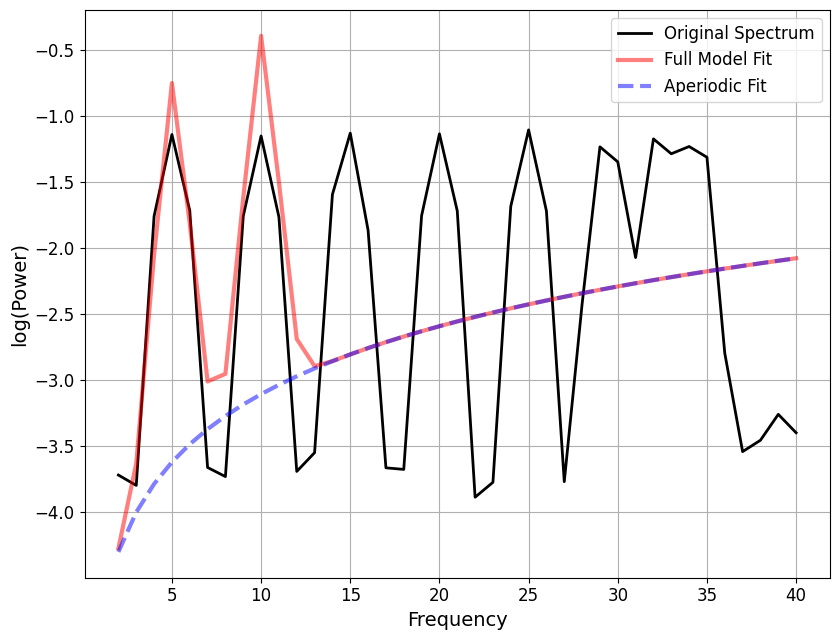

In [5]:
# Adding oscillations with increasing numbers of peaks to white noise

components = {
        'sim_oscillation': [{'freq' : 5}, {'freq' : 10}, {'freq' : 15}, {'freq' : 20}, {'freq' : 25}, {'freq' : 30}, {'freq' : 33}, {'freq' : 35}],
        'sim_powerlaw' : {'exponent' : 0}}

# Combing white noise signal and peaks
sig = sim_combined(n_seconds, s_rate, components)

# Computing power spectra
com_freqs, com_powers = compute_spectrum_welch(sig, s_rate)

# Initialising Spectral Model
fm_com = SpectralModel()

# Setting frequency range
freq_range = [2, 40]

# Fitting and plotting model
fm_com.fit(com_freqs, com_powers, freq_range)
fm_com.plot()

# Printing aperiodic offset and exponent 
print ('Aperiodic parameters: \n', fm_com.results.params.aperiodic.params, '\n')

#### Pink noise


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic parameters: 
 [-1.98923799  0.82767815] 



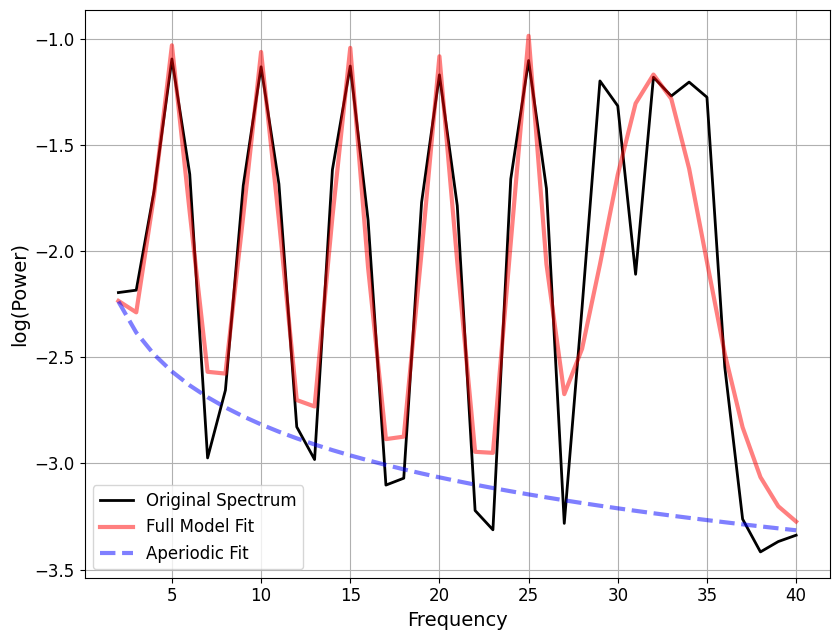

In [7]:
# Adding oscillations increasing numbers of peaks to pink noise

components = {
        'sim_oscillation': [{'freq' : 5}, {'freq' : 10}, {'freq' : 15}, {'freq' : 20}, {'freq' : 25}, {'freq' : 30}, {'freq' : 33}, {'freq' : 35}],
        'sim_powerlaw' : {'exponent' : -1}}

# Combing pink noise signal and peaks
sig = sim_combined(n_seconds, s_rate, components)

# Computing power spectra
com_freqs, com_powers = compute_spectrum_welch(sig, s_rate)

# Initialising Spectral Model
fm_com = SpectralModel()

# Setting frequency range
freq_range = [2, 40]

# Fitting and plotting model
fm_com.fit(com_freqs, com_powers, freq_range)
fm_com.plot()

# Printing aperiodic offset and exponent 
print ('Aperiodic parameters: \n', fm_com.results.params.aperiodic.params, '\n')

#### Brown noise


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic parameters: 
 [-0.50121215  3.11281519] 



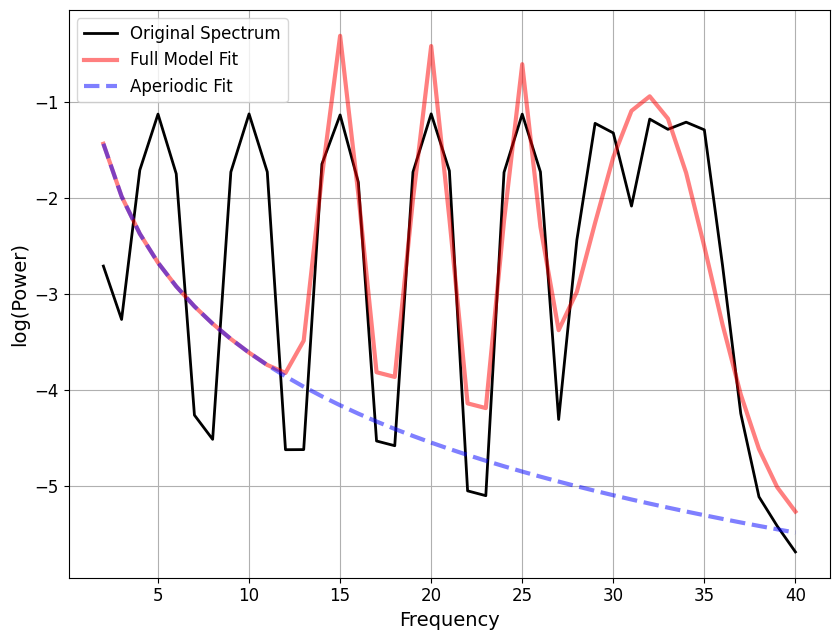

In [8]:
# Adding oscillations increasing numbers of peaks to brown noise

components = {
        'sim_oscillation': [{'freq' : 5}, {'freq' : 10}, {'freq' : 15}, {'freq' : 20}, {'freq' : 25}, {'freq' : 30}, {'freq' : 33}, {'freq' : 35}],
        'sim_powerlaw' : {'exponent' : -2}}

# Combing brown noise signal and peaks
sig = sim_combined(n_seconds, s_rate, components)

# Computing power spectra
com_freqs, com_powers = compute_spectrum_welch(sig, s_rate)

# Initialising Spectral Model
fm_com = SpectralModel()

# Setting frequency range
freq_range = [2, 40]

# Fitting and plotting model
fm_com.fit(com_freqs, com_powers, freq_range)
fm_com.plot()

# Printing aperiodic offset and exponent 
print ('Aperiodic parameters: \n', fm_com.results.params.aperiodic.params, '\n')